# regressão linear regularizada para preço de passagens

**objetivo:** montar uma primeira versão de modelo para prever `price`, usando os sinais encontrados no eda.

**ideia do notebook**

- começar com um baseline simples, só com `duration` e `days_left`
- adicionar `class` e `stops`, que apareceram fortes no eda
- testar se `route` e os horários ajudam o modelo
- comparar `LinearRegression` com uma versão regularizada simples (`Ridge`)
- comparar `price` cru e `log1p(price)`

**observação**

- eu não usei `flight` nesta primeira versão porque quis manter o modelo mais simples e evitar uma feature muito específica logo de início

In [1]:
import os
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
warnings.filterwarnings("ignore")


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [
        cwd,
        cwd.parent,
        cwd / "03-flight-price-prediction",
        cwd.parent / "03-flight-price-prediction",
    ]
    for candidate in candidates:
        if (candidate / "data" / "Clean_Dataset.csv").exists():
            return candidate
    raise FileNotFoundError("nao encontrei data/Clean_Dataset.csv")


PROJECT_ROOT = resolve_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "Clean_Dataset.csv"

os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / "notebooks" / ".mplconfig"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

PALETA_GRAFICOS = [
    "#A8DADC",
    "#FFCAD4",
    "#CDEAC0",
    "#C7CEEA",
    "#FFD6A5",
    "#BDE0FE",
    "#E4C1F9",
    "#F1C0E8",
]

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid")
sns.set_palette(PALETA_GRAFICOS)
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=PALETA_GRAFICOS)
RANDOM_STATE = 42

In [2]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

df = pd.read_csv(DATA_PATH).drop(columns=["Unnamed: 0"]).copy()
df["route"] = df["source_city"] + " -> " + df["destination_city"]

display(df.head())
print(f"shape da base de modelagem: {df.shape}")

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,route
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.1700,1,5953,Delhi -> Mumbai
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.3300,1,5953,Delhi -> Mumbai
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.1700,1,5956,Delhi -> Mumbai
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.2500,1,5955,Delhi -> Mumbai
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.3300,1,5955,Delhi -> Mumbai


shape da base de modelagem: (300153, 12)


## 1. split treino e teste

- separação 80/20 entre treino e teste
- uso `stratify=class` para preservar a proporção entre `Economy` e `Business`
- como o eda mostrou base sem nulos, o pré-processamento fica mais simples


In [4]:
target = df["price"]


def split_xy(cols):
    X = df[cols].copy()
    y = target.copy()
    return train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=df["class"],
    )


def build_preprocessor(X):
    num_cols = X.select_dtypes(include="number").columns.tolist()
    cat_cols = X.select_dtypes(exclude="number").columns.tolist()
    preprocessor = ColumnTransformer(
        [
            ("num", StandardScaler(), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), cat_cols),
        ]
    )
    return preprocessor


def evaluate_predictions(y_true, y_pred):
    return {
        "rmse": root_mean_squared_error(y_true, y_pred),
        "mae": mean_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred),
    }

agrupar por localização geográfica
transformar em bins - para quantidades muito grandes de categóricas

colunas - multiplicar uma coluna com a outra para correlações não lineares - mapear relações complexas/não lineares
multiplicar colunas para ver relação que não seja linear

## 2. experimentos alinhados ao eda

conjuntos de features comparados:

1. `baseline_num`: só `duration + days_left`
2. `core_eda`: adiciona `class + stops`
3. `with_route`: adiciona `route`
4. `with_times`: adiciona `departure_time + arrival_time`

em cada setup, comparo `LinearRegression` vs `Ridge(alpha=1.0)` e `price` cru vs `log1p(price)`.


In [5]:
feature_sets = {
    "baseline_num": ["duration", "days_left"],
    "core_eda": ["class", "stops", "duration", "days_left"],
    "with_route": ["route", "class", "stops", "duration", "days_left"],
    "with_times": ["route", "class", "stops", "departure_time", "arrival_time", "duration", "days_left"],
}

models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
}

experiment_store = {}
rows = []

for feature_set_name, cols in feature_sets.items():
    X_train, X_test, y_train, y_test = split_xy(cols)
    preprocessor = build_preprocessor(X_train)

    for target_mode in ["raw", "log1p"]:
        y_train_fit = np.log1p(y_train) if target_mode == "log1p" else y_train

        for model_name, model in models.items():
            pipe = Pipeline(
                [
                    ("pre", preprocessor),
                    ("model", model),
                ]
            )
            pipe.fit(X_train, y_train_fit)

            pred_train = pipe.predict(X_train)
            pred_test = pipe.predict(X_test)

            if target_mode == "log1p":
                pred_train = np.expm1(pred_train)
                pred_test = np.expm1(pred_test)

            pred_train = np.clip(pred_train, a_min=0, a_max=None)
            pred_test = np.clip(pred_test, a_min=0, a_max=None)

            train_metrics = evaluate_predictions(y_train, pred_train)
            test_metrics = evaluate_predictions(y_test, pred_test)

            key = (feature_set_name, target_mode, model_name)
            experiment_store[key] = {
                "pipe": pipe,
                "X_train": X_train,
                "X_test": X_test,
                "y_train": y_train,
                "y_test": y_test,
                "pred_train": pred_train,
                "pred_test": pred_test,
            }

            rows.append(
                {
                    "feature_set": feature_set_name,
                    "target_mode": target_mode,
                    "model": model_name,
                    "rmse_train": train_metrics["rmse"],
                    "rmse_test": test_metrics["rmse"],
                    "mae_test": test_metrics["mae"],
                    "r2_test": test_metrics["r2"],
                    "generalization_gap": test_metrics["rmse"] - train_metrics["rmse"],
                }
            )

results_df = pd.DataFrame(rows).sort_values("rmse_test").reset_index(drop=True)
display(results_df.round(4))

,feature_set,target_mode,model,rmse_train,rmse_test,mae_test,r2_test,generalization_gap
0,with_times,raw,LinearRegression,"6,827.2927","6,860.9278","4,530.6758",0.9088,33.6351
1,with_times,raw,Ridge,"6,827.3824","6,860.9847","4,530.7145",0.9088,33.6022
2,with_route,raw,LinearRegression,"6,865.6551","6,900.2279","4,552.0130",0.9078,34.5728
3,with_route,raw,Ridge,"6,865.6856","6,900.2539","4,551.9345",0.9078,34.5683
4,core_eda,raw,LinearRegression,"7,034.3952","7,066.5989","4,578.0487",0.9033,32.2037
5,core_eda,raw,Ridge,"7,034.4164","7,066.6219","4,578.0904",0.9033,32.2055
6,with_times,log1p,Ridge,"8,359.5391","8,397.3015","4,912.7972",0.8634,37.7624
7,with_times,log1p,LinearRegression,"8,360.2616","8,397.7046","4,912.8876",0.8634,37.4430
8,with_route,log1p,Ridge,"8,401.2969","8,439.7230","4,948.7913",0.8620,38.4261
9,with_route,log1p,LinearRegression,"8,401.8265","8,439.9288","4,948.8096",0.8620,38.1023


## 3. leitura comparativa

sinais que eu queria confirmar aqui:

- `baseline_num` sozinho deve ficar fraco
- `class` deve trazer o maior salto inicial no modelo
- `route` e horários podem melhorar mais um pouco o ajuste
- `Ridge` deve ficar próximo da regressão linear
- `raw` e `log1p` precisam ser comparados na escala original do preço


,feature_set,target_mode,model,rmse_test,mae_test,r2_test,generalization_gap
0,with_times,raw,LinearRegression,"6,860.9278","4,530.6758",0.9088,33.6351
1,with_times,raw,Ridge,"6,860.9847","4,530.7145",0.9088,33.6022
2,with_route,raw,LinearRegression,"6,900.2279","4,552.0130",0.9078,34.5728
3,with_route,raw,Ridge,"6,900.2539","4,551.9345",0.9078,34.5683
4,core_eda,raw,LinearRegression,"7,066.5989","4,578.0487",0.9033,32.2037
5,core_eda,raw,Ridge,"7,066.6219","4,578.0904",0.9033,32.2055
6,with_times,log1p,Ridge,"8,397.3015","4,912.7972",0.8634,37.7624
7,with_times,log1p,LinearRegression,"8,397.7046","4,912.8876",0.8634,37.4430
8,with_route,log1p,Ridge,"8,439.7230","4,948.7913",0.8620,38.4261
9,with_route,log1p,LinearRegression,"8,439.9288","4,948.8096",0.8620,38.1023


,feature_set,target_mode,model,rmse_test,r2_test
0,baseline_num,log1p,LinearRegression,"24,031.0538",-0.1186
1,baseline_num,raw,Ridge,"22,180.8371",0.0470
2,core_eda,log1p,Ridge,"8,499.6357",0.8601
3,core_eda,raw,LinearRegression,"7,066.5989",0.9033
4,with_route,log1p,Ridge,"8,439.7230",0.8620
5,with_route,raw,LinearRegression,"6,900.2279",0.9078
6,with_times,log1p,Ridge,"8,397.3015",0.8634
7,with_times,raw,LinearRegression,"6,860.9278",0.9088


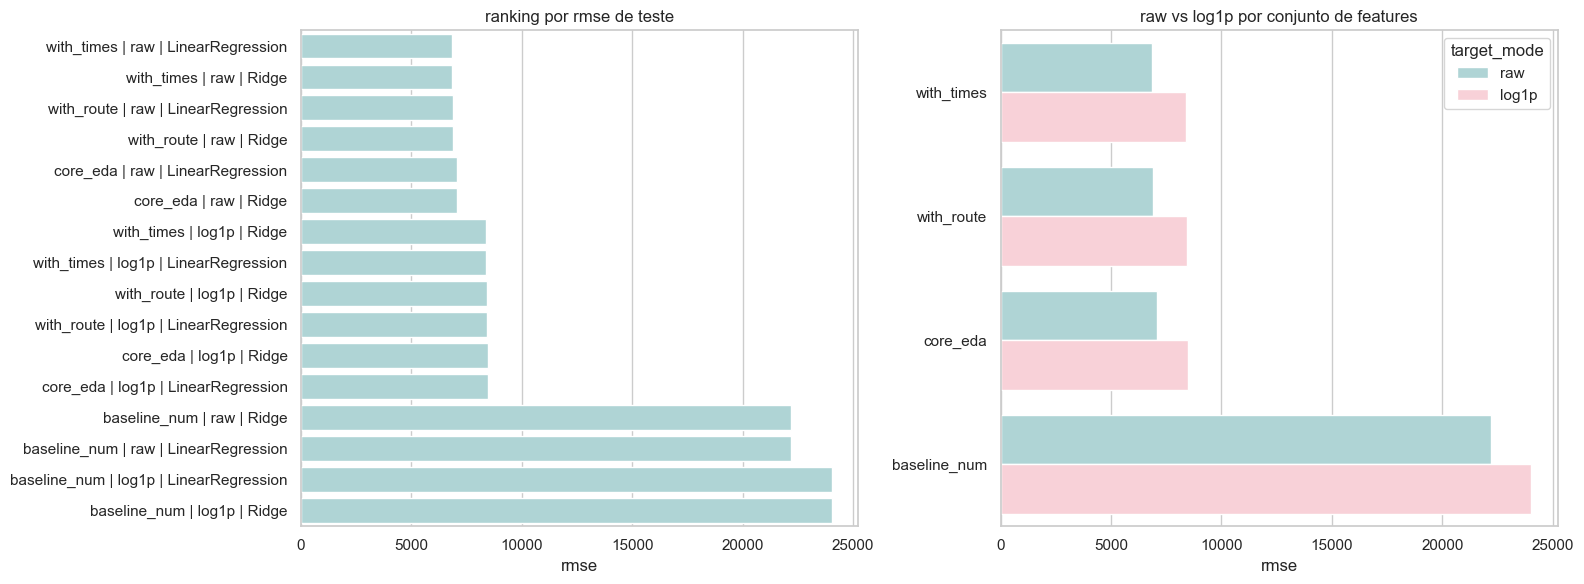

In [6]:
results_view = results_df[["feature_set", "target_mode", "model", "rmse_test", "mae_test", "r2_test", "generalization_gap"]].copy()
display(results_view.round(4))

best_by_setup = (
    results_df.sort_values("rmse_test")
    .groupby(["feature_set", "target_mode"], as_index=False)
    .first()[["feature_set", "target_mode", "model", "rmse_test", "r2_test"]]
)
display(best_by_setup.round(4))

ranking_df = results_df.copy()
ranking_df["setup"] = ranking_df["feature_set"] + " | " + ranking_df["target_mode"] + " | " + ranking_df["model"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(
    data=ranking_df.sort_values("rmse_test"),
    x="rmse_test",
    y="setup",
    color=PALETA_GRAFICOS[0],
    ax=axes[0],
)
axes[0].set_title("ranking por rmse de teste")
axes[0].set_xlabel("rmse")
axes[0].set_ylabel("")

sns.barplot(
    data=best_by_setup.sort_values("rmse_test"),
    x="rmse_test",
    y="feature_set",
    hue="target_mode",
    ax=axes[1],
)
axes[1].set_title("raw vs log1p por conjunto de features")
axes[1].set_xlabel("rmse")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

o ranking mostra que o baseline com apenas `duration` e `days_left` fica muito fraco, então essas variáveis sozinhas não conseguem explicar bem o preço. 
existe uma mudança de cenário quando `class` e `stops` entram no modelo, o que confirma diretamente o que já apareceu no eda. depois disso, `route` melhora um pouco mais o ajuste, e os horários trazem um ganho adicional menor, mas ainda consistente.

também fica claro que, nesta base, usar `price` cru funcionou melhor do que `log1p(price)` quando a comparação é feita pela métrica na escala original. por fim, `LinearRegression` e `Ridge` ficaram praticamente empatados em todos os setups, então a regularização não mudou muito a performance, mas o `Ridge` continua sendo uma escolha razoável por entregar quase o mesmo resultado com uma solução mais estável

## 4. melhor modelo

agora eu pego o melhor resultado da tabela anterior para fazer uma leitura simples do desempenho no teste.

nesta etapa, eu fico só com diagnósticos mais diretos:

- métricas principais
- alguns exemplos de previsão
- gráfico `predito vs real`
- distribuição dos resíduos


,value
feature_set,with_times
target_mode,raw
model,LinearRegression
rmse_test,"6,860.9278"
mae_test,"4,530.6758"
r2_test,0.9088
generalization_gap,33.6351


,price_real,price_predito,erro_abs
238918,45805,"52,935.1700","7,130.1700"
279020,74970,"51,817.6100","23,152.3900"
235023,51405,"56,680.2900","5,275.2900"
204259,6032,"7,645.6200","1,613.6200"
219604,54273,"50,741.5400","3,531.4600"
46475,2339,0.0000,"2,339.0000"
90463,3466,"4,519.5900","1,053.5900"
47380,2738,0.0000,"2,738.0000"
216561,65529,"56,689.0600","8,839.9400"
100906,6578,"7,228.0200",650.0200


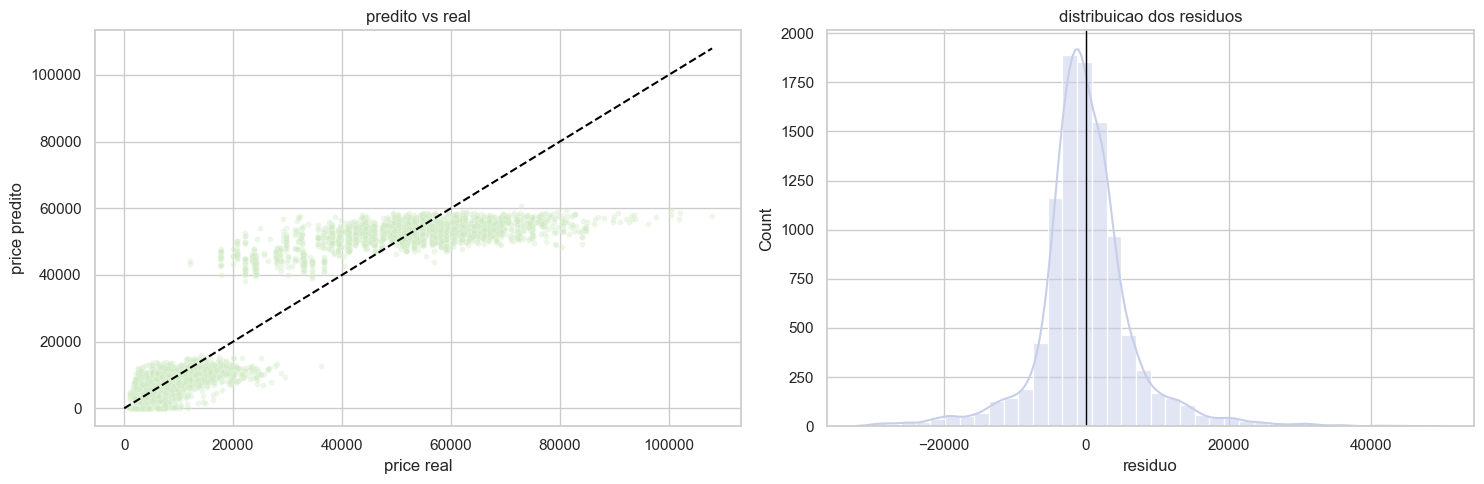

In [7]:
best_row = results_df.iloc[0]
best_key = (best_row["feature_set"], best_row["target_mode"], best_row["model"])
best_artifact = experiment_store[best_key]

pred_test = pd.Series(best_artifact["pred_test"], index=best_artifact["y_test"].index)
comparison_df = pd.DataFrame(
    {
        "price_real": best_artifact["y_test"],
        "price_predito": pred_test,
    }
).assign(erro_abs=lambda d: (d["price_real"] - d["price_predito"]).abs())

diagnostics = pd.Series(
    {
        "feature_set": best_row["feature_set"],
        "target_mode": best_row["target_mode"],
        "model": best_row["model"],
        "rmse_test": best_row["rmse_test"],
        "mae_test": best_row["mae_test"],
        "r2_test": best_row["r2_test"],
        "generalization_gap": best_row["generalization_gap"],
    }
).to_frame("value")

display(diagnostics)
display(comparison_df.sample(10, random_state=RANDOM_STATE).round(2))

sample_idx = best_artifact["y_test"].sample(10000, random_state=RANDOM_STATE).index
sample_df = comparison_df.loc[sample_idx].copy()
sample_df["residuo"] = sample_df["price_real"] - sample_df["price_predito"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(
    data=sample_df,
    x="price_real",
    y="price_predito",
    alpha=0.35,
    s=18,
    color=PALETA_GRAFICOS[2],
    ax=axes[0],
)
line_min = min(sample_df["price_real"].min(), sample_df["price_predito"].min())
line_max = max(sample_df["price_real"].max(), sample_df["price_predito"].max())
axes[0].plot([line_min, line_max], [line_min, line_max], color="black", linestyle="--")
axes[0].set_title("predito vs real")
axes[0].set_xlabel("price real")
axes[0].set_ylabel("price predito")

sns.histplot(sample_df["residuo"], bins=40, kde=True, ax=axes[1], color=PALETA_GRAFICOS[3])
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("distribuicao dos residuos")
axes[1].set_xlabel("residuo")

plt.tight_layout()
plt.show()

nesta execução, o melhor resultado ficou com o setup `with_times`, usando `price` em escala original e `LinearRegression`. o `Ridge` ficou muito próximo, então na prática houve um empate técnico, mas a menor métrica de teste ficou com a regressão linear. por isso, os gráficos finais mostram o comportamento desse modelo.

## 5. leitura final

- `duration` e `days_left` sozinhos ficam muito fracos para prever `price`
- o maior salto vem quando `class` e `stops` entram no modelo, o que conversa diretamente com o eda
- `route` melhora mais um pouco o ajuste, e os horários trazem um ganho adicional pequeno, mas consistente
- nesta comparação, `price` cru funcionou melhor do que `log1p(price)` quando a avaliação foi feita na escala original
- `Ridge` e `LinearRegression` ficaram praticamente empatados, então faz sentido manter `Ridge` como escolha final por ser uma versão regularizada simples
- mesmo sem usar `flight`, o melhor setup já explica cerca de 90% da variação do preço, então ele funciona bem como primeira versão de modelo
